In [10]:
# Step 1 — Import required libraries
import pandas as pd
import numpy as np
from pathlib import Path

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [11]:
# Step 2 — Define data path and load interactions dataset
DATA_PATH = Path("../../data/raw")

# Load interactions dataset
df = pd.read_csv(DATA_PATH / "interactions.csv")

# Convert timestamp column to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Data loaded successfully ✅")
df.head()

Data loaded successfully ✅


,user_id,reel_id,view,watch_ratio,like,comment,purchase,timestamp
0,1,1191,1,0.84,0,0,0,2025-12-12 15:49:21.170953
1,1,2506,1,0.71,0,1,0,2025-12-28 15:49:21.544868
2,1,1764,1,0.67,0,0,0,2026-02-18 15:49:21.340695
3,1,2777,1,0.91,1,0,0,2026-02-17 15:49:21.619322
4,1,1074,1,0.70,0,0,0,2026-02-09 15:49:21.135591


In [12]:
# Step 3 — Compute baseline popularity score for each row
# We assign weights to different interaction types: views, watch_ratio, likes, comments, purchases

df['popularity_score'] = (
    1 * df['view'] +
    2 * df['watch_ratio'] +
    3 * df['like'] +
    2 * df['comment'] +
    5 * df['purchase']
)

print("Popularity score calculated ✅")
df[['reel_id', 'popularity_score']].head()

Popularity score calculated ✅


,reel_id,popularity_score
0,1191,2.68
1,2506,4.42
2,1764,2.34
3,2777,5.82
4,1074,2.40


In [13]:
# Step 4 — Aggregate scores per reel
popularity = df.groupby('reel_id')['popularity_score'].sum().reset_index()

# Sort reels by popularity descending
popularity = popularity.sort_values('popularity_score', ascending=False)

print("Aggregated popularity per reel ✅")
popularity.head(10)

Aggregated popularity per reel ✅


,reel_id,popularity_score
1059,1060,152.94
2548,2549,152.08
2620,2621,148.34
673,674,146.88
1728,1729,146.64
1463,1464,144.54
464,465,143.24
2277,2278,142.20
124,125,141.30
2850,2851,138.46


In [14]:
# Step 5 — Define recommendation function
def recommend_popular(top_k=10):
    """
    Returns top_k most popular reels based on the baseline popularity score
    """
    return popularity.head(top_k)['reel_id'].tolist()

# Example usage
recommend_popular(10)

[1060, 2549, 2621, 674, 1729, 1464, 465, 2278, 125, 2851]

In [15]:
## Step 6 — Save the popularity scores to processed folder
processed_path = Path("../../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

popularity.to_csv(
    processed_path / "popularity_scores.csv",
    index=False
)

print("Popularity scores saved successfully ✅")

Popularity scores saved successfully ✅


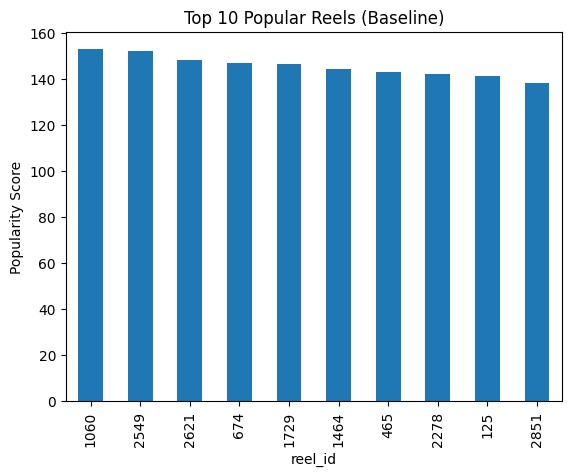

In [16]:
# Step 7 — Simple bar plot for top 10 reels
import matplotlib.pyplot as plt

popularity.head(10).plot.bar(x='reel_id', y='popularity_score', legend=False)
plt.title("Top 10 Popular Reels (Baseline)")
plt.ylabel("Popularity Score")
plt.show()